# Multi-Label Species Predictor for H3 Hexes in Spain

Predicts which threatened species are likely present in an H3 hex (top 20 threatened). Compares MLP, K-NN, LightGBM, XGBoost.

**Output:** Top-N species with probabilities: `[{"species_id": ..., "name": ..., "p": 0.99}, ...]`

In [152]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

COUNTRY = "ES"
H3_RES = 7
PARENT_RES = 5  # for spatial block split (coarser than H3_RES)
YEAR_START = 2015
YEAR_END = 2024
TARGET_YEAR = 2024  # Y = presence in this year only
FEATURE_YEARS = (2019, 2023)  # last 5 years before TARGET_YEAR for features (no leakage)
N_THREATENED = 20  # top 20 threatened species
N_INVASIVE = 0  # threatened only
PRESENCE_THRESHOLD = 2  # min occurrence_count to count as presence (configurable)
EFFORT_THRESHOLD = 200  # obs_count_all >= this for high-effort hexes (mask-and-recover)
MASK_FRACTION = 0.2  # fraction of positives to mask in evaluation
K_LIST = [1, 2, 3, 4, 5, 10, 20]
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15

# S3 paths (DuckDB/s3fs pattern from streamlit app)
S3_BUCKET = "ie-datalake"
GOLD_H3_MAPPING = "gold/gbif_species_h3_mapping"
GOLD_SPECIES_DIM = "gold/gbif_species_dim"
GOLD_OSM_HEX = "gold/osm_hex_features"
GOLD_CELL_METRICS = "gold/gbif_cell_metrics"
GOLD_NATURE2000 = "gold/nature2000_cell_protection"
GOLD_GEE_TERRAIN = "gold/gee_hex_terrain"  # elevation, slope, land cover % from GEE
GEE_TERRAIN_SNAPSHOT = "2019"  # land cover year (partition key)
NATURE2000_SNAPSHOT_DATE = "2026-02-27"
AWS_PROFILE = "486717354268_PowerUserAccess"

# Optional: local Parquet paths (override S3 when set)
# LOCAL_H3_MAPPING = "/path/to/gbif_species_h3_mapping"
# LOCAL_OSM = "/path/to/osm_hex_features"
# LOCAL_CELL_METRICS = "/path/to/gbif_cell_metrics"
LOCAL_H3_MAPPING = None
LOCAL_OSM = None
LOCAL_CELL_METRICS = None

# Models
KNN_K = 5  # neighbors for K-NN
LGBM_N_ESTIMATORS = 200
LGBM_LEARNING_RATE = 0.05
HIDDEN_SIZES = [256, 128]
DROPOUT = 0.3
BATCH_SIZE = 64
MAX_EPOCHS = 200
PATIENCE = 25
LEARNING_RATE = 1e-3

# Output
OUTPUT_DIR = "output"
MODEL_PATH = f"{OUTPUT_DIR}/species_predictor.pt"
LGBM_MODEL_PATH = f"{OUTPUT_DIR}/species_predictor_lgbm.pkl"
XGB_MODEL_PATH = f"{OUTPUT_DIR}/species_predictor_xgb.pkl"
TARGET_SPECIES_PATH = f"{OUTPUT_DIR}/target_species.csv"
SCALER_PATH = f"{OUTPUT_DIR}/scaler.pkl"

In [ ]:
# Dependencies (run once)
%pip install -q pandas numpy scikit-learn torch h3 pyarrow boto3 lightgbm xgboost shap matplotlib

In [153]:
from __future__ import annotations

import logging
import os
import random
import warnings
from pathlib import Path
from typing import Any

import h3
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from torch.utils.data import DataLoader, TensorDataset

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger("species_predictor")

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

## A) Data Loading

Load hex-species mapping, OSM features, and cell metrics from S3. Same mechanism as src notebooks: boto3 session + PyArrow S3FileSystem.

In [154]:
# ─── S3 connection (same as src/gbif_silver_to_gold_dim.ipynb) ─────────────────────
import boto3
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.fs as pafs

session = boto3.Session(profile_name=AWS_PROFILE)
creds = session.get_credentials().get_frozen_credentials()
region = session.region_name or "eu-west-2"

fs_read = pafs.S3FileSystem(
    access_key=creds.access_key,
    secret_key=creds.secret_key,
    session_token=creds.token,
    region=region,
)

pa.set_io_thread_count(min(16, (os.cpu_count() or 4) * 2))
pa.set_cpu_count(os.cpu_count() or 4)

log.info("S3 ready (profile=%s, region=%s)", AWS_PROFILE, region)

01:43:25 [INFO] Found credentials in shared credentials file: ~/.aws/credentials
01:43:25 [INFO] S3 ready (profile=486717354268_PowerUserAccess, region=eu-west-2)


In [155]:
def _read_parquet_partition(native_path: str) -> pd.DataFrame:
    """Read Parquet partition from S3 using PyArrow (same as src notebooks)."""
    dataset = ds.dataset(native_path, filesystem=fs_read, format="parquet")
    table = dataset.scanner(use_threads=True).to_table()
    return table.to_pandas()

def load_h3_mapping(years: list[int]) -> pd.DataFrame:
    """Load gbif_species_h3_mapping for ES, h3_res=7, across years."""
    if LOCAL_H3_MAPPING:
        return pd.read_parquet(LOCAL_H3_MAPPING)
    parts = []
    for year in years:
        native_path = f"{S3_BUCKET}/{GOLD_H3_MAPPING}/country={COUNTRY}/year={year}/h3_resolution={H3_RES}"
        try:
            df = _read_parquet_partition(native_path)
            parts.append(df)
        except Exception as e:
            log.warning("Skip %s: %s", native_path, e)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

def load_osm_hex_features() -> pd.DataFrame:
    """Load osm_hex_features for ES, h3_res=7."""
    if LOCAL_OSM:
        return pd.read_parquet(LOCAL_OSM)
    native_path = f"{S3_BUCKET}/{GOLD_OSM_HEX}/country={COUNTRY}/h3_resolution={H3_RES}"
    try:
        return _read_parquet_partition(native_path)
    except Exception as e:
        log.warning("Skip %s: %s", native_path, e)
        return pd.DataFrame()

def load_cell_metrics(years: list[int]) -> pd.DataFrame:
    """Load gbif_cell_metrics for obs_count_all, dq_score (effort/confidence)."""
    if LOCAL_CELL_METRICS:
        return pd.read_parquet(LOCAL_CELL_METRICS)
    parts = []
    for year in years:
        native_path = f"{S3_BUCKET}/{GOLD_CELL_METRICS}/country={COUNTRY}/year={year}/h3_resolution={H3_RES}"
        try:
            df = _read_parquet_partition(native_path)
            df["year"] = year
            parts.append(df)
        except Exception as e:
            log.warning("Skip %s: %s", native_path, e)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

def load_species_dim(year: int) -> pd.DataFrame:
    """Load gbif_species_dim for species names."""
    if LOCAL_H3_MAPPING:
        return pd.DataFrame()
    native_path = f"{S3_BUCKET}/{GOLD_SPECIES_DIM}/country={COUNTRY}/year={year}"
    try:
        return _read_parquet_partition(native_path)
    except Exception as e:
        log.warning("Skip %s: %s", native_path, e)
        return pd.DataFrame()

def load_nature2000() -> pd.DataFrame:
    """Load nature2000_cell_protection for ES, h3_res=7."""
    native_path = f"{S3_BUCKET}/{GOLD_NATURE2000}/country={COUNTRY}/h3_resolution={H3_RES}/snapshot_date={NATURE2000_SNAPSHOT_DATE}"
    try:
        return _read_parquet_partition(native_path)
    except Exception as e:
        log.warning("Skip %s: %s", native_path, e)
        return pd.DataFrame()

def load_gee_hex_terrain() -> pd.DataFrame:
    """Load gee_hex_terrain (elevation_mean, slope_mean, lc_*_pct) for ES, h3_res=7."""
    native_path = f"{S3_BUCKET}/{GOLD_GEE_TERRAIN}/country={COUNTRY}/snapshot={GEE_TERRAIN_SNAPSHOT}/h3_resolution={H3_RES}"
    try:
        return _read_parquet_partition(native_path)
    except Exception as e:
        log.warning("Skip %s: %s", native_path, e)
        return pd.DataFrame()

In [156]:
years = list(range(YEAR_START, YEAR_END + 1))
log.info("Loading data for years %s...", years)

df_h3 = load_h3_mapping(years)
df_osm = load_osm_hex_features()
df_cell = load_cell_metrics(years)
df_nature2000 = load_nature2000()
df_gee_terrain = load_gee_hex_terrain()
df_species = load_species_dim(YEAR_END) if not df_h3.empty else pd.DataFrame()

# Normalize column names (h3_index vs h3_id)
h3_col = "h3_index" if "h3_index" in df_h3.columns else "h3_id"
if "h3_id" in df_osm.columns and "h3_index" not in df_osm.columns:
    df_osm = df_osm.rename(columns={"h3_id": "h3_index"})
if "h3_id" in df_cell.columns and "h3_index" not in df_cell.columns:
    df_cell = df_cell.rename(columns={"h3_id": "h3_index"})
if not df_nature2000.empty and "h3_id" in df_nature2000.columns and "h3_index" not in df_nature2000.columns:
    df_nature2000 = df_nature2000.rename(columns={"h3_id": "h3_index"})

# taxon_key vs species_id
species_id_col = "taxon_key" if "taxon_key" in df_h3.columns else "species_id"

if not df_gee_terrain.empty and "h3_id" in df_gee_terrain.columns and "h3_index" not in df_gee_terrain.columns:
    df_gee_terrain = df_gee_terrain.rename(columns={"h3_id": "h3_index"})

log.info("h3_mapping: %d rows, osm: %d rows, cell_metrics: %d rows, nature2000: %d rows, gee_terrain: %d rows",
         len(df_h3), len(df_osm), len(df_cell), len(df_nature2000), len(df_gee_terrain))

01:43:30 [INFO] Loading data for years [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]...
01:43:45 [INFO] h3_mapping: 10578566 rows, osm: 94574 rows, cell_metrics: 575568 rows, nature2000: 129741 rows, gee_terrain: 95481 rows


## A) Data Preparation

1. Filter to country=ES, h3_res=7
2. Build target species list (top N threatened by total occurrences)
3. Create hex-level presence labels
4. Build feature matrix with OSM, effort, neighbor aggregates

In [157]:
# 1) Filter and normalize
df_h3 = df_h3[df_h3["country"].astype(str) == COUNTRY].copy()
df_h3 = df_h3[df_h3["h3_resolution"] == H3_RES].copy()
if "year_month" in df_h3.columns and "year" not in df_h3.columns:
    df_h3["year"] = df_h3["year_month"].str[:4].astype(int)
df_h3["year"] = pd.to_numeric(df_h3["year"], errors="coerce").astype("Int64")

# 2) Build target species list
def _is_threatened(row) -> bool:
    if pd.notna(row.get("is_threatened")) and bool(row["is_threatened"]):
        return True
    cat = str(row.get("iucn_category", "")).upper()
    return cat in ("CR", "EN", "VU")

def _is_invasive(row) -> bool:
    return pd.notna(row.get("is_invasive")) and bool(row["is_invasive"])

# Aggregate occurrences per species in ES
occ = df_h3.groupby(species_id_col).agg({
    "occurrence_count": "sum",
    "is_threatened": "max",  # True if any row is True
    "is_invasive": "max",
}).reset_index()
if "iucn_category" in df_h3.columns:
    iucn = df_h3.groupby(species_id_col)["iucn_category"].first().reset_index()
    occ = occ.merge(iucn, on=species_id_col, how="left")
else:
    occ["iucn_category"] = None

occ["_threatened"] = occ.apply(_is_threatened, axis=1)
occ["_invasive"] = occ.apply(_is_invasive, axis=1)

threatened = occ[occ["_threatened"]].nlargest(N_THREATENED, "occurrence_count")[species_id_col].tolist()
invasive = occ[occ["_invasive"]].nlargest(N_INVASIVE, "occurrence_count")[species_id_col].tolist()

if len(threatened) < N_THREATENED:
    log.warning("Only %d threatened species (requested %d)", len(threatened), N_THREATENED)
if len(invasive) < N_INVASIVE:
    log.warning("Only %d invasive species (requested %d)", len(invasive), N_INVASIVE)

target_species_ids = list(dict.fromkeys(threatened + invasive))  # preserve order, no dupes
log.info("Target species: %d total (%d threatened, %d invasive)", len(target_species_ids), len(threatened), len(invasive))
assert len(target_species_ids) > 0, "No target species found"

# Species names for feature column names (in_hex_last5y, in_k1_last5y, in_k2_last5y)
species_names = {}
if not df_species.empty and "species_name" in df_species.columns:
    id_col = "taxon_key" if "taxon_key" in df_species.columns else "species_id"
    species_names = dict(zip(df_species[id_col], df_species["species_name"]))

01:43:55 [INFO] Target species: 20 total (20 threatened, 0 invasive)


In [158]:
# 3) Create hex-level presence labels
# Y = presence in TARGET_YEAR (2024) only. Hexes = union of 2019-2024 for feature coverage.
df_h3_target = df_h3[
    (df_h3["year"] == TARGET_YEAR) &
    (df_h3[species_id_col].isin(target_species_ids)) &
    (df_h3["occurrence_count"] >= PRESENCE_THRESHOLD)
].copy()
df_h3_feature = df_h3[
    (df_h3["year"].between(FEATURE_YEARS[0], FEATURE_YEARS[1])) &
    (df_h3[species_id_col].isin(target_species_ids)) &
    (df_h3["occurrence_count"] >= PRESENCE_THRESHOLD)
].copy()

# Y: presence in 2024
presence_target = df_h3_target.groupby([h3_col, species_id_col]).size().reset_index(name="_cnt")
# Hexes: union of hexes with presence in 2019-2024 (for features + labels)
hexes_feature = df_h3_feature[h3_col].unique()
hexes_target = df_h3_target[h3_col].unique()
hexes = np.unique(np.concatenate([hexes_feature, hexes_target]))

species_to_idx = {s: i for i, s in enumerate(target_species_ids)}
Y = np.zeros((len(hexes), len(target_species_ids)), dtype=np.float32)
hex_to_row = {h: i for i, h in enumerate(hexes)}
for _, row in presence_target.iterrows():
    r, c = hex_to_row[row[h3_col]], species_to_idx[row[species_id_col]]
    Y[r, c] = 1.0

# Presence in 2019-2023 (for features, no leakage)
presence_last5 = df_h3_feature.groupby([h3_col, species_id_col]).size().reset_index(name="_cnt")
Y_last5 = np.zeros((len(hexes), len(target_species_ids)), dtype=np.float32)
for _, row in presence_last5.iterrows():
    if row[h3_col] in hex_to_row:
        r, c = hex_to_row[row[h3_col]], species_to_idx[row[species_id_col]]
        Y_last5[r, c] = 1.0

df_hexes = pd.DataFrame({h3_col: hexes})
log.info("Hex-level samples: %d, Y (2024) shape: %s, Y_last5 (2019-2023) for features", len(hexes), Y.shape)

01:43:58 [INFO] Hex-level samples: 18775, Y (2024) shape: (18775, 20), Y_last5 (2019-2023) for features


In [159]:
# 4) Build feature matrix X
import re
right_col = "h3_index" if "h3_index" in df_osm.columns else "h3_id"
df_feat = df_hexes.merge(df_osm, left_on=h3_col, right_on=right_col, how="left", suffixes=("", "_osm"))
if f"{right_col}_osm" in df_feat.columns:
    df_feat = df_feat.drop(columns=[f"{right_col}_osm"])
elif right_col != h3_col and right_col in df_feat.columns:
    df_feat = df_feat.drop(columns=[right_col])
df_feat = df_feat.rename(columns={"h3_index" if "h3_index" in df_feat.columns else "h3_id": h3_col})

# Natura 2000 (is_protected_area, nearest_protected_distance)
if not df_nature2000.empty:
    n2k_col = "h3_index" if "h3_index" in df_nature2000.columns else "h3_id"
    n2k = df_nature2000[[n2k_col, "is_protected_area", "nearest_protected_distance"]].copy()
    n2k = n2k.rename(columns={n2k_col: h3_col})
    n2k["is_protected_area"] = (n2k["is_protected_area"].astype(str).str.lower() == "yes").astype(np.float32)
    n2k["nearest_protected_distance"] = pd.to_numeric(n2k["nearest_protected_distance"], errors="coerce").fillna(-1).astype(np.float32)
    df_feat = df_feat.merge(n2k, on=h3_col, how="left")

# GEE hex terrain: elevation_mean, slope_mean, lc_*_pct (land cover proportions)
if not df_gee_terrain.empty:
    gee_col = "h3_index" if "h3_index" in df_gee_terrain.columns else "h3_id"
    gee_cols = [c for c in df_gee_terrain.columns if c != gee_col and c != "h3_resolution"]
    df_gee_sub = df_gee_terrain[[gee_col] + gee_cols].rename(columns={gee_col: h3_col})
    df_feat = df_feat.merge(df_gee_sub, on=h3_col, how="left")

# OSM features + optional dist_to_coast_m, dist_to_major_road_m
OSM_COLS = [
    "road_count", "major_road_count", "road_count_per_km2",
    "port_feature_count", "airport_feature_count",
    "urban_footprint_area_pct", "building_area_pct", "protected_area_pct",
    "building_count", "waterbody_area_pct", "wetland_area_pct",
    "human_footprint_area_pct", "natural_habitat_area_pct",
    "dist_to_coast_m", "dist_to_major_road_m",
]
osm_avail = [c for c in OSM_COLS if c in df_feat.columns]
NATURE2000_COLS = ["is_protected_area", "nearest_protected_distance"]
n2k_avail = [c for c in NATURE2000_COLS if c in df_feat.columns]

# Effort/confidence from cell_metrics (2019-2023 only to avoid leakage)
df_cell_effort = df_cell
if not df_cell.empty and "year" in df_cell.columns:
    df_cell_effort = df_cell[df_cell["year"].between(FEATURE_YEARS[0], FEATURE_YEARS[1])]
if not df_cell_effort.empty:
    obs_col = "observation_count" if "observation_count" in df_cell_effort.columns else "obs_count_all"
    if obs_col in df_cell_effort.columns:
        cell_agg = df_cell_effort.groupby("h3_index" if "h3_index" in df_cell_effort.columns else "h3_id").agg({
            obs_col: "sum",
            **({"dqi": "mean"} if "dqi" in df_cell_effort.columns else {}),
        }).reset_index()
        cell_agg = cell_agg.rename(columns={"h3_index" if "h3_index" in cell_agg.columns else "h3_id": h3_col})
        if obs_col in cell_agg.columns:
            cell_agg["log_obs_count"] = np.log1p(cell_agg[obs_col].fillna(0))
        df_feat = df_feat.merge(cell_agg, on=h3_col, how="left")

# Neighbor aggregates (k=1 adjacency)
def neighbor_mean_obs(h3_id: str, obs_map: dict) -> float:
    try:
        neighbors = h3.grid_disk(h3_id, 1)
        vals = [obs_map.get(n, 0) for n in neighbors if n != h3_id]
        return np.mean(vals) if vals else 0.0
    except Exception:
        return 0.0

if not df_cell.empty and "log_obs_count" in df_feat.columns:
    obs_map = dict(zip(df_feat[h3_col], df_feat["log_obs_count"].fillna(0)))
    df_feat["neighbor_log_obs_mean"] = df_feat[h3_col].map(lambda h: neighbor_mean_obs(h, obs_map))

# Historical presence features (2019-2023 only, no leakage): in_hex_last5y, in_k1_last5y, in_k2_last5y
def _slug(s: str, sid, prefix: str) -> str:
    base = re.sub(r'[^a-z0-9]+', '_', str(s).lower())[:30].strip('_')
    return f"{prefix}_{base}" if base else f"{prefix}_{sid}"

def _make_cols(prefix: str) -> list:
    cols, seen = [], set()
    for sid in target_species_ids:
        name = species_names.get(sid, str(sid))
        col = _slug(name, sid, prefix)
        if col in seen or col in df_feat.columns:
            col = f"{prefix}_{sid}"
        seen.add(col)
        cols.append(col)
    return cols

in_hex_cols = _make_cols("in_hex_last5y")
in_k1_cols = _make_cols("in_k1_last5y")
in_k2_cols = _make_cols("in_k2_last5y")

in_hex_vals = np.zeros((len(df_feat), len(target_species_ids)), dtype=np.float32)
in_k1_vals = np.zeros((len(df_feat), len(target_species_ids)), dtype=np.float32)
in_k2_vals = np.zeros((len(df_feat), len(target_species_ids)), dtype=np.float32)

for i in range(len(df_feat)):
    h = df_feat.iloc[i][h3_col]
    if h not in hex_to_row:
        continue
    row_self = hex_to_row[h]
    in_hex_vals[i, :] = Y_last5[row_self, :]
    try:
        k1_set = set(h3.grid_disk(h, 1))
        k2_set = set(h3.grid_disk(h, 2)) - k1_set
        k1_set.discard(h)
        for n in k1_set:
            if n in hex_to_row:
                in_k1_vals[i, :] = np.maximum(in_k1_vals[i, :], Y_last5[hex_to_row[n], :])
        for n in k2_set:
            if n in hex_to_row:
                in_k2_vals[i, :] = np.maximum(in_k2_vals[i, :], Y_last5[hex_to_row[n], :])
    except Exception:
        pass

for j, c in enumerate(in_hex_cols):
    df_feat[c] = in_hex_vals[:, j].astype(np.float32)
for j, c in enumerate(in_k1_cols):
    df_feat[c] = in_k1_vals[:, j].astype(np.float32)
for j, c in enumerate(in_k2_cols):
    df_feat[c] = in_k2_vals[:, j].astype(np.float32)

hist_cols = in_hex_cols + in_k1_cols + in_k2_cols

# GEE terrain: elevation, slope, land cover proportions (from gee_hex_terrain gold)
TERRAIN_COLS = ["elevation_mean", "slope_mean"] + [c for c in df_feat.columns if c.startswith("lc_") and c.endswith("_pct")]
terrain_avail = [c for c in TERRAIN_COLS if c in df_feat.columns]
FEATURE_COLS = osm_avail + n2k_avail + (["log_obs_count", "dqi", "neighbor_log_obs_mean"] if "log_obs_count" in df_feat.columns else []) + hist_cols + terrain_avail
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_feat.columns]
if not FEATURE_COLS:
    df_feat["_const"] = 1.0
    FEATURE_COLS = ["_const"]
    log.warning("No OSM/cell features found; using constant placeholder")

# Replace inf/nan and clip to avoid float32 overflow
X_raw = df_feat[FEATURE_COLS].fillna(0).replace([np.inf, -np.inf], 0)
X_raw = np.clip(X_raw.values.astype(np.float64), -1e15, 1e15).astype(np.float32)
log.info("Feature cols: %d total (%d hist: in_hex_last5y, in_k1_last5y, in_k2_last5y)", len(FEATURE_COLS), len(hist_cols))

01:44:03 [INFO] Feature cols: 103 total (60 hist: in_hex_last5y, in_k1_last5y, in_k2_last5y)


In [160]:
# 5) Normalize and build target species mapping
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# Target species dataframe (species_names from target species cell)
df_target = pd.DataFrame({
    "target_idx": range(len(target_species_ids)),
    "species_id": target_species_ids,
    "species_name": [species_names.get(s, str(s)) for s in target_species_ids],
    "is_threatened": [s in threatened for s in target_species_ids],
    "is_invasive": [s in invasive for s in target_species_ids],
})
df_target.to_csv(TARGET_SPECIES_PATH, index=False)
log.info("X: %s, Y: %s", X.shape, Y.shape)

01:44:08 [INFO] X: (18775, 103), Y: (18775, 20)


## C) Spatial Block Split (mandatory)

Split by parent H3 block to avoid leakage from nearby hexes.

In [161]:
# Spatial block id: parent H3 at coarse resolution
def get_block_id(h3_id: str) -> str:
    try:
        return h3.cell_to_parent(h3_id, PARENT_RES)
    except Exception:
        return str(hash(h3_id) % 10000)

df_feat["block_id"] = df_feat[h3_col].map(get_block_id)
blocks = df_feat["block_id"].unique()
random.seed(42)
np.random.seed(42)
random.shuffle(blocks)
n = len(blocks)
t_end = int(n * TRAIN_FRAC)
v_end = int(n * (TRAIN_FRAC + VAL_FRAC))
train_blocks, val_blocks, test_blocks = set(blocks[:t_end]), set(blocks[t_end:v_end]), set(blocks[v_end:])

train_mask = df_feat["block_id"].isin(train_blocks).values
val_mask = df_feat["block_id"].isin(val_blocks).values
test_mask = df_feat["block_id"].isin(test_blocks).values

X_train, X_val, X_test = X[train_mask], X[val_mask], X[test_mask]
Y_train, Y_val, Y_test = Y[train_mask], Y[val_mask], Y[test_mask]
hex_train = df_feat.loc[train_mask, h3_col].values
hex_val = df_feat.loc[val_mask, h3_col].values
hex_test = df_feat.loc[test_mask, h3_col].values

# High-effort hexes (for mask-and-recover)
obs_col = "observation_count" if "observation_count" in df_cell.columns else "obs_count_all"
if not df_cell.empty and obs_col in df_cell.columns:
    cell_obs = df_cell.groupby("h3_index" if "h3_index" in df_cell.columns else "h3_id")[obs_col].sum()
    df_feat["obs_count_all"] = df_feat[h3_col].map(cell_obs).fillna(0)
else:
    df_feat["obs_count_all"] = 0  # no data -> treat all as low effort; mask-and-recover uses subset

high_effort_mask = (df_feat["obs_count_all"] >= EFFORT_THRESHOLD).values
log.info("Train %d, val %d, test %d; high-effort hexes: %d", X_train.shape[0], X_val.shape[0], X_test.shape[0], high_effort_mask.sum())

01:44:12 [INFO] Train 12951, val 2856, test 2968; high-effort hexes: 13089


## B) Multi-Label Neural Network (PyTorch)

MLP with sigmoid output, BCEWithLogitsLoss, class weights (pos_weight) for imbalance.

In [162]:
class MultiLabelMLP(nn.Module):
    def __init__(self, n_features: int, n_targets: int, hidden_sizes: list[int] = None, dropout: float = 0.3):
        super().__init__()
        hidden_sizes = hidden_sizes or [256, 128]
        layers = []
        prev = n_features
        for h in hidden_sizes:
            layers.extend([
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(prev, n_targets)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.backbone(x))

def compute_pos_weight(Y: np.ndarray) -> torch.Tensor:
    """pos_weight = (num_neg / num_pos) per class for BCEWithLogitsLoss."""
    n_pos = Y.sum(axis=0) + 1e-6
    n_neg = Y.shape[0] - n_pos + 1e-6
    return torch.tensor((n_neg / n_pos).astype(np.float32))

In [163]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_features = X_train.shape[1]
n_targets = Y_train.shape[1]
pos_weight = compute_pos_weight(Y_train).to(device)

model = MultiLabelMLP(n_features, n_targets, HIDDEN_SIZES, DROPOUT).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

def macro_pr_auc(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Macro PR-AUC across species."""
    n_classes = y_true.shape[1]
    scores = []
    for c in range(n_classes):
        if y_true[:, c].sum() > 0:
            scores.append(average_precision_score(y_true[:, c], y_pred[:, c]))
        else:
            scores.append(0.0)
    return np.mean(scores) if scores else 0.0

def micro_pr_auc(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return average_precision_score(y_true.ravel(), y_pred.ravel())

## B3) XGBoost (GridSearch + tuning)

Oddzielny trening XGBoost z GridSearchCV. Najlepszy model zapisywany do `output/species_predictor_xgb.pkl`.

In [164]:
# XGBoost GridSearch + training + evaluation
import xgboost as xgb
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import GridSearchCV
import pickle

# GridSearch na jednym gatunku (szybsze), potem MultiOutput z best params
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "min_child_weight": [1, 3],
}
xgb_base = xgb.XGBClassifier(random_state=42, n_jobs=-1)
grid = GridSearchCV(
    xgb_base,
    param_grid,
    cv=3,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1,
)
# Fit on first species only for speed (binary)
grid.fit(X_train, Y_train[:, 0])
log.info("Best XGBoost params: %s", grid.best_params_)
best_params = grid.best_params_

# Train full MultiOutput with best params
xgb_multi = MultiOutputClassifier(
    xgb.XGBClassifier(**best_params, random_state=42, n_jobs=-1),
    n_jobs=1,
)
xgb_multi.fit(X_train, Y_train)
probs_xgb = np.column_stack([p[:, 1] for p in xgb_multi.predict_proba(X_test)]).astype(np.float32)

# Save
with open(XGB_MODEL_PATH, "wb") as f:
    pickle.dump({"model": xgb_multi, "scaler": scaler, "feature_cols": FEATURE_COLS, "best_params": best_params}, f)
log.info("Saved XGBoost to %s", XGB_MODEL_PATH)

# Evaluation (XGBoost only)
def _recall_at_k(y_true, y_pred, k):
    n, rec = y_true.shape[0], 0.0
    for i in range(n):
        n_pos = y_true[i].sum()
        rec += 1.0 if n_pos == 0 else y_true[i, np.argsort(-y_pred[i])[:k]].sum() / n_pos
    return rec / n
def _precision_at_k(y_true, y_pred, k):
    n, prec = y_true.shape[0], 0.0
    for i in range(n):
        topk = np.argsort(-y_pred[i])[:k]
        prec += y_true[i, topk].sum() / len(topk) if len(topk) else 1.0
    return prec / n
def macro_pr_auc(y_true, y_pred):
    scores = []
    for c in range(y_true.shape[1]):
        if y_true[:, c].sum() > 0:
            scores.append(average_precision_score(y_true[:, c], y_pred[:, c]))
    return np.mean(scores) if scores else 0.0
def micro_pr_auc(y_true, y_pred):
    return average_precision_score(y_true.ravel(), y_pred.ravel())

k_vals = [1, 2, 3, 4, 5, 10, 20]
ma = macro_pr_auc(Y_test, probs_xgb)
mi = micro_pr_auc(Y_test, probs_xgb)
rs = [_recall_at_k(Y_test, probs_xgb, k) for k in k_vals]
ps = [_precision_at_k(Y_test, probs_xgb, k) for k in k_vals]
log.info("=== XGBoost (tuned) test metrics ===")
log.info("Macro PR-AUC: %.4f, Micro PR-AUC: %.4f", ma, mi)
print("XGBoost (tuned) | Macro: %.4f | Micro: %.4f" % (ma, mi))
print("Recall:  ", " ".join(["R@%d: %.4f" % (k, r) for k, r in zip(k_vals, rs)]))
print("Precision:", " ".join(["P@%d: %.4f" % (k, p) for k, p in zip(k_vals, ps)]))

Fitting 3 folds for each of 24 candidates, totalling 72 fits


01:44:33 [INFO] Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 100}
01:44:35 [INFO] Saved XGBoost to output/species_predictor_xgb.pkl
01:44:36 [INFO] === XGBoost (tuned) test metrics ===
01:44:36 [INFO] Macro PR-AUC: 0.4477, Micro PR-AUC: 0.5306


XGBoost (tuned) | Macro: 0.4477 | Micro: 0.5306
Recall:   R@1: 0.7857 R@2: 0.8916 R@3: 0.9356 R@4: 0.9626 R@5: 0.9785 R@10: 0.9965 R@20: 1.0000
Precision: P@1: 0.2999 P@2: 0.2353 P@3: 0.1849 P@4: 0.1520 P@5: 0.1282 P@10: 0.0680 P@20: 0.0343


In [165]:
# Training with early stopping on validation macro PR-AUC
train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(Y_train, dtype=torch.float32),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

best_val_auc = 0.0
patience_counter = 0

for epoch in range(MAX_EPOCHS):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        logits_val = model(torch.tensor(X_val, dtype=torch.float32).to(device))
        probs_val = torch.sigmoid(logits_val).cpu().numpy()
    val_auc = macro_pr_auc(Y_val, probs_val)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        torch.save({"model": model.state_dict(), "scaler": scaler, "feature_cols": FEATURE_COLS}, MODEL_PATH)
        log.info("Epoch %d: val macro PR-AUC %.4f (best)", epoch + 1, val_auc)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            log.info("Early stopping at epoch %d", epoch + 1)
            break

# Load best
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model"])

01:45:46 [INFO] Epoch 1: val macro PR-AUC 0.3971 (best)
01:45:47 [INFO] Epoch 2: val macro PR-AUC 0.4028 (best)
01:45:47 [INFO] Epoch 3: val macro PR-AUC 0.4186 (best)
01:45:47 [INFO] Epoch 4: val macro PR-AUC 0.4360 (best)
01:45:48 [INFO] Epoch 6: val macro PR-AUC 0.4439 (best)
01:45:48 [INFO] Epoch 7: val macro PR-AUC 0.4447 (best)
01:45:48 [INFO] Epoch 8: val macro PR-AUC 0.4538 (best)
01:45:48 [INFO] Epoch 9: val macro PR-AUC 0.4561 (best)
01:45:49 [INFO] Epoch 13: val macro PR-AUC 0.4630 (best)
01:45:50 [INFO] Epoch 14: val macro PR-AUC 0.4631 (best)
01:45:50 [INFO] Epoch 17: val macro PR-AUC 0.4634 (best)
01:45:51 [INFO] Epoch 20: val macro PR-AUC 0.4640 (best)
01:45:51 [INFO] Epoch 21: val macro PR-AUC 0.4758 (best)
01:45:52 [INFO] Epoch 22: val macro PR-AUC 0.4787 (best)
01:45:55 [INFO] Epoch 35: val macro PR-AUC 0.4931 (best)
01:45:55 [INFO] Epoch 36: val macro PR-AUC 0.4950 (best)
01:46:02 [INFO] Early stopping at epoch 61


<All keys matched successfully>

## D) Metrics & Evaluation

Macro/Micro PR-AUC, Recall@K, Precision@K, mask-and-recover, baselines.

In [166]:
def recall_at_k(y_true: np.ndarray, y_pred: np.ndarray, k: int) -> float:
    """Per-hex: fraction of true present species found in top-K."""
    n = y_true.shape[0]
    rec = 0.0
    for i in range(n):
        n_pos = y_true[i].sum()
        if n_pos == 0:
            rec += 1.0
            continue
        topk = np.argsort(-y_pred[i])[:k]
        found = y_true[i, topk].sum()
        rec += found / n_pos
    return rec / n

def precision_at_k(y_true: np.ndarray, y_pred: np.ndarray, k: int) -> float:
    """Per-hex: fraction of top-K that are truly present."""
    n = y_true.shape[0]
    prec = 0.0
    for i in range(n):
        topk = np.argsort(-y_pred[i])[:k]
        n_topk = len(topk)
        if n_topk == 0:
            prec += 1.0
            continue
        found = y_true[i, topk].sum()
        prec += found / n_topk
    return prec / n

# Test set predictions
model.eval()
with torch.no_grad():
    probs_test = torch.sigmoid(model(torch.tensor(X_test, dtype=torch.float32).to(device))).cpu().numpy()

# K-NN & LightGBM (compute here so evaluation cell is self-contained)
from sklearn.metrics.pairwise import cosine_similarity
nn_sim = cosine_similarity(X_test, X_train)
probs_knn = np.zeros_like(Y_test, dtype=np.float32)
for i in range(X_test.shape[0]):
    neighbors = np.argsort(-nn_sim[i])[:KNN_K]
    probs_knn[i] = Y_train[neighbors].mean(axis=0)

import lightgbm as lgb
import xgboost as xgb
from sklearn.multioutput import MultiOutputClassifier
lgb_base = lgb.LGBMClassifier(n_estimators=LGBM_N_ESTIMATORS, learning_rate=LGBM_LEARNING_RATE, max_depth=6, num_leaves=31, verbose=-1, random_state=42, n_jobs=-1)
lgb_multi = MultiOutputClassifier(lgb_base, n_jobs=1)
lgb_multi.fit(X_train, Y_train)
probs_lgbm = np.column_stack([p[:, 1] for p in lgb_multi.predict_proba(X_test)]).astype(np.float32)

# XGBoost: use tuned model from B3 cell above; fallback if B3 not run
try:
    _ = probs_xgb
except NameError:
    xgb_base = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
    xgb_multi = MultiOutputClassifier(xgb_base, n_jobs=1)
    xgb_multi.fit(X_train, Y_train)
    probs_xgb = np.column_stack([p[:, 1] for p in xgb_multi.predict_proba(X_test)]).astype(np.float32)
    log.warning("XGBoost: quick fit (run B3 for GridSearch)")
import pickle
with open(LGBM_MODEL_PATH, "wb") as f:
    pickle.dump({"model": lgb_multi, "scaler": scaler, "feature_cols": FEATURE_COLS}, f)

# Compare all models: MLP, K-NN, LightGBM, XGBoost, Most frequent
models = {
    "MLP": probs_test,
    "K-NN": probs_knn,
    "LightGBM": probs_lgbm,
    "XGBoost": probs_xgb,
}

# Most frequent baseline
species_freq = Y_train.sum(axis=0)
baseline_order = np.argsort(-species_freq)
probs_baseline = np.zeros_like(probs_test)
for i in range(probs_test.shape[0]):
    for j, idx in enumerate(baseline_order[:max(K_LIST)]):
        probs_baseline[i, idx] = 1.0 - j * 0.01
models["Most frequent"] = probs_baseline

log.info("=== Model comparison (test set) ===")
k_vals = [1, 2, 3, 4, 5, 10, 20]
hdr = f"{'Model':<14} {'Macro':>8} {'Micro':>8}" + "".join([("R@"+str(k)).rjust(8) for k in k_vals]) + "".join([("P@"+str(k)).rjust(8) for k in k_vals])
print(hdr)
print("-" * len(hdr))
for name, probs in models.items():
    ma = macro_pr_auc(Y_test, probs)
    mi = micro_pr_auc(Y_test, probs)
    rs = [recall_at_k(Y_test, probs, k) for k in k_vals]
    ps = [precision_at_k(Y_test, probs, k) for k in k_vals]
    row = f"{name:<14} {ma:>8.4f} {mi:>8.4f}" + "".join([f"{r:>8.4f}" for r in rs]) + "".join([f"{p:>8.4f}" for p in ps])
    print(row)

# Save showcase_data for 04_species_showcase_map.ipynb (run this cell to create it)
SHOWCASE_PATH = f"{OUTPUT_DIR}/showcase_data.pkl"
with open(SHOWCASE_PATH, "wb") as f:
    pickle.dump({"df_feat": df_feat, "Y": Y, "hex_test": hex_test, "X_test": X[test_mask], "Y_test": Y[test_mask], "target_species_ids": target_species_ids, "species_names": species_names, "FEATURE_COLS": FEATURE_COLS, "h3_col": h3_col}, f)
log.info("Saved showcase_data to %s", SHOWCASE_PATH)

/Users/jakubizewski/Desktop/repos/ie-microsoft-capstone/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jakubizewski/Desktop/repos/ie-microsoft-capstone/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jakubizewski/Desktop/repos/ie-microsoft-capstone/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jakubizewski/Desktop/repos/ie-microsoft-capstone/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jakubizewski/Desktop/repos/ie

Model             Macro    Micro     R@1     R@2     R@3     R@4     R@5    R@10    R@20     P@1     P@2     P@3     P@4     P@5    P@10    P@20
------------------------------------------------------------------------------------------------------------------------------------------------
MLP              0.4345   0.4248  0.7606  0.8703  0.9292  0.9596  0.9782  0.9972  1.0000  0.2655  0.2182  0.1792  0.1494  0.1269  0.0682  0.0343
K-NN             0.2869   0.3033  0.7386  0.8221  0.8586  0.8752  0.8816  0.9127  1.0000  0.2443  0.1887  0.1497  0.1214  0.1005  0.0553  0.0343
LightGBM         0.4407   0.5105  0.7800  0.8863  0.9340  0.9623  0.9748  0.9958  1.0000  0.2931  0.2315  0.1839  0.1517  0.1268  0.0678  0.0343
XGBoost          0.4477   0.5306  0.7857  0.8916  0.9356  0.9626  0.9785  0.9965  1.0000  0.2999  0.2353  0.1849  0.1520  0.1282  0.0680  0.0343
Most frequent    0.0381   0.1001  0.6445  0.7328  0.7881  0.8196  0.8510  0.9582  1.0000  0.1290  0.1324  0.1128  0.0983  0.0892  

### SHAP interpretability (XGBoost)

TreeExplainer on first species classifier. Shows which features drive predictions.

/var/folders/7t/yrpkmv3n0vj6ml2djk_2bdk80000gn/T/ipykernel_17514/979405883.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS, show=False, max_display=20)


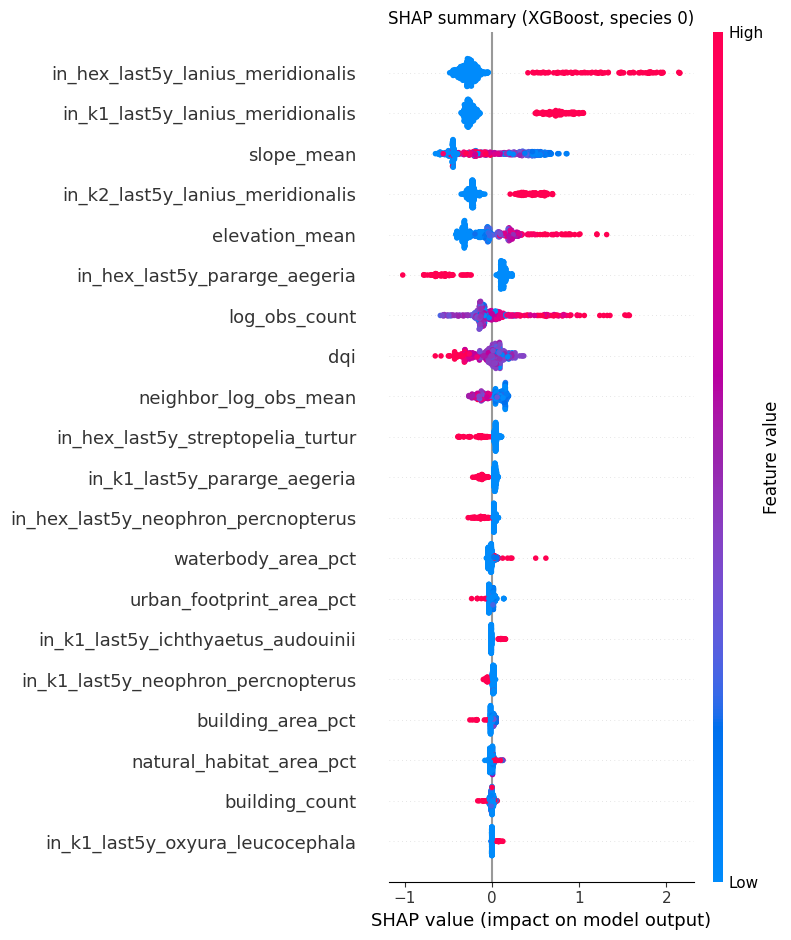

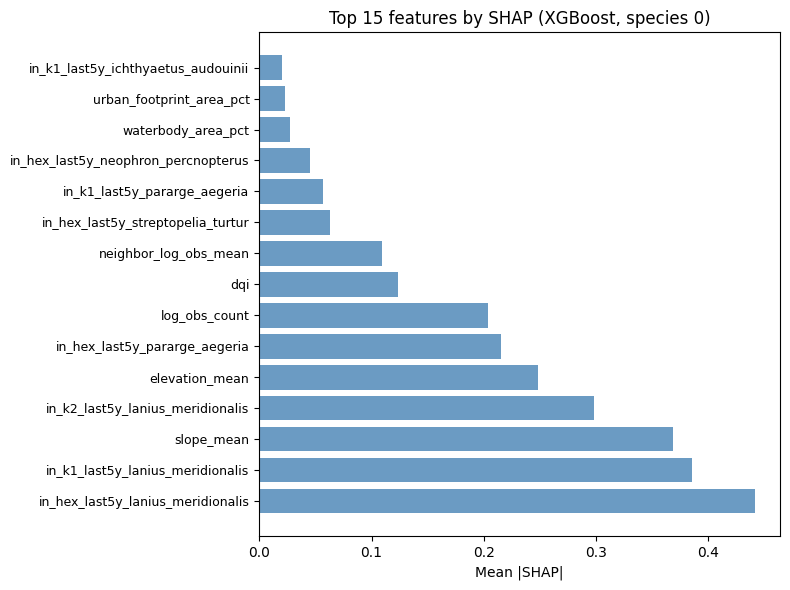

In [167]:
# SHAP values (XGBoost – TreeExplainer, sample for speed)
import shap

# Use first XGBoost estimator (first species) for interpretability
n_sample = min(500, X_test.shape[0])  # subsample for speed
X_sample = X_test[:n_sample]
explainer = shap.TreeExplainer(xgb_multi.estimators_[0], X_sample)
sv = explainer.shap_values(X_sample)
shap_values = sv[1] if isinstance(sv, list) and len(sv) == 2 else sv

# Summary plot: mean |SHAP| per feature
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS, show=False, max_display=20)
plt.title("SHAP summary (XGBoost, species 0)")
plt.tight_layout()
plt.show()

# Bar plot: mean absolute SHAP (simpler)
shap_means = np.abs(shap_values).mean(axis=0)
idx = np.argsort(shap_means)[-15:]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(idx)), shap_means[idx], color="steelblue", alpha=0.8)
ax.set_yticks(range(len(idx)))
ax.set_yticklabels([FEATURE_COLS[i] for i in idx], fontsize=9)
ax.set_xlabel("Mean |SHAP|")
ax.set_title("Top 15 features by SHAP (XGBoost, species 0)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## D2) Visual Model Analysis

Visualizations: per-species PR-AUC, Recall@K, feature importance (LightGBM), prediction distribution, calibration.

IndexError: boolean index did not match indexed array along axis 0; size of axis is 2968 but size of corresponding boolean axis is 59360

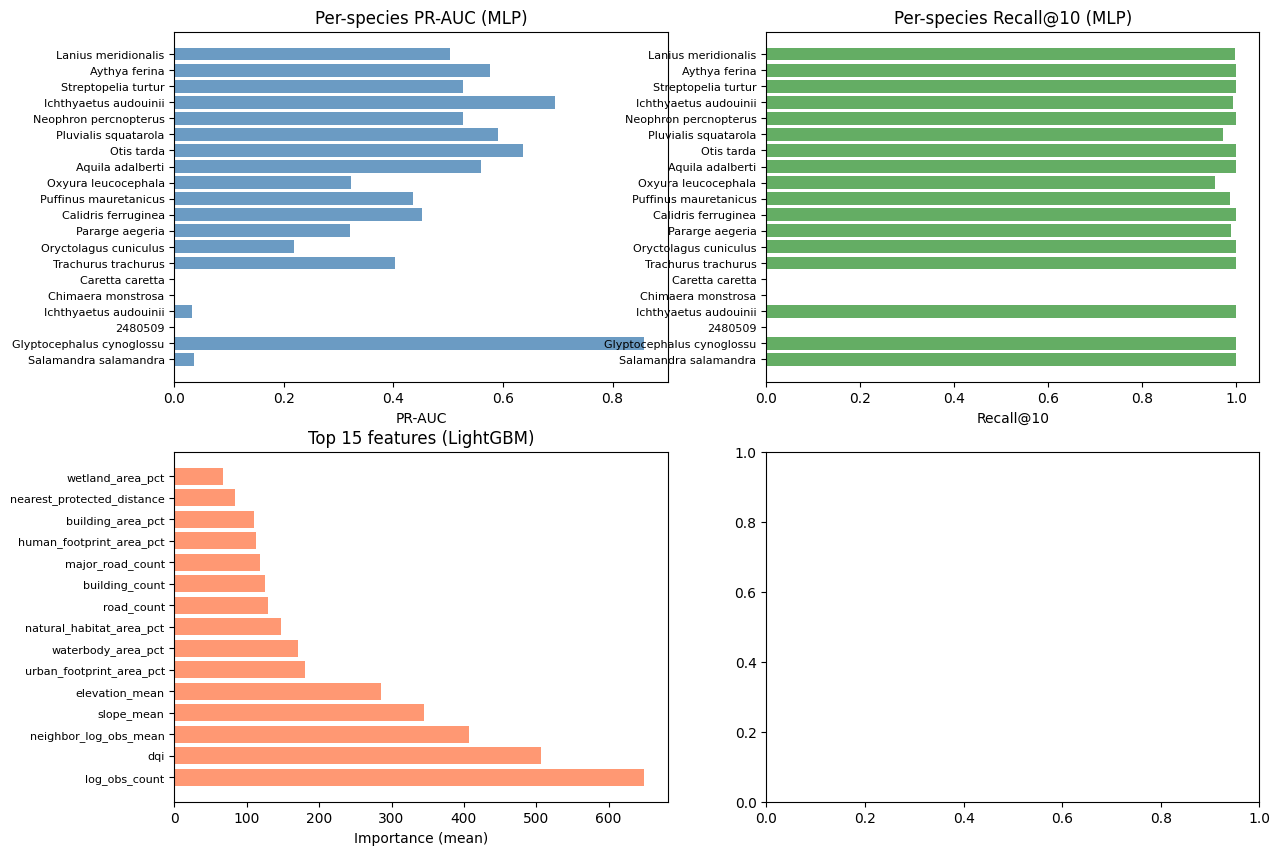

In [149]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Per-species Macro PR-AUC (MLP)
species_auc = []
for c in range(Y_test.shape[1]):
    if Y_test[:, c].sum() > 0:
        species_auc.append(average_precision_score(Y_test[:, c], probs_test[:, c]))
    else:
        species_auc.append(0.0)
names = [str(df_target.iloc[i]["species_name"])[:25] for i in range(len(species_auc))]
ax = axes[0, 0]
bars = ax.barh(range(len(species_auc)), species_auc, color="steelblue", alpha=0.8)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel("PR-AUC")
ax.set_title("Per-species PR-AUC (MLP)")
ax.invert_yaxis()

# 2) Per-species Recall@10 (MLP)
species_r10 = []
for c in range(Y_test.shape[1]):
    n_pos = Y_test[:, c].sum()
    if n_pos == 0:
        species_r10.append(0.0)
        continue
    found = 0
    for i in range(Y_test.shape[0]):
        if Y_test[i, c] > 0:
            topk = np.argsort(-probs_test[i])[:10]
            if c in topk:
                found += 1
    species_r10.append(found / max(1, (Y_test[:, c] > 0).sum()))
ax = axes[0, 1]
ax.barh(range(len(species_r10)), species_r10, color="forestgreen", alpha=0.7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel("Recall@10")
ax.set_title("Per-species Recall@10 (MLP)")
ax.invert_yaxis()

# 3) Feature importance (LightGBM – mean across species)
imp = np.zeros(len(FEATURE_COLS))
for est in lgb_multi.estimators_:
    imp += est.feature_importances_
imp /= len(lgb_multi.estimators_)
idx = np.argsort(imp)[-15:]
ax = axes[1, 0]
ax.barh(range(len(idx)), imp[idx], color="coral", alpha=0.8)
ax.set_yticks(range(len(idx)))
ax.set_yticklabels([FEATURE_COLS[i] for i in idx], fontsize=8)
ax.set_xlabel("Importance (mean)")
ax.set_title("Top 15 features (LightGBM)")
ax.invert_yaxis()

# 4) Prediction confidence distribution
ax = axes[1, 1]
ax.hist(probs_test[Y_test.ravel() > 0], bins=30, alpha=0.7, label="True positive", color="green", density=True)
ax.hist(probs_test[Y_test.ravel() == 0], bins=30, alpha=0.5, label="True negative", color="gray", density=True)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Density")
ax.set_title("Prediction distribution (MLP)")
ax.legend()

plt.tight_layout()
plt.show()

In [150]:
# Mask-and-recover: restrict to high-effort hexes, mask 20% of positives, check if they appear in top-K
def recall_masked_positives(Y_true: np.ndarray, Y_pred: np.ndarray, mask_indices: list[tuple], k: int) -> float:
    """Fraction of masked positives that appear in top-K predictions."""
    if not mask_indices:
        return 0.0
    recovered = 0
    for r, c in mask_indices:
        topk = np.argsort(-Y_pred[r])[:k]
        if c in topk:
            recovered += 1
    return recovered / len(mask_indices)

test_high_effort = high_effort_mask[test_mask]
Y_test_he = Y_test[test_high_effort]
probs_test_he = probs_test[test_high_effort]
if Y_test_he.shape[0] > 0:
    mask_rng = np.random.RandomState(42)
    positive_indices = list(zip(*np.where(Y_test_he > 0)))
    n_pos = len(positive_indices)
    n_mask = max(1, int(n_pos * MASK_FRACTION))
    to_mask = mask_rng.choice(n_pos, size=n_mask, replace=False)
    masked_pairs = [positive_indices[i] for i in to_mask]
    log.info("=== Mask-and-recover (high-effort hexes, %d masked positives) ===", len(masked_pairs))
    for k in K_LIST:
        r = recall_masked_positives(Y_test_he, probs_test_he, masked_pairs, k)
        log.info("Recall@%d (masked positives): %.4f", k, r)
else:
    log.info("No high-effort test hexes for mask-and-recover")

01:35:58 [INFO] === Mask-and-recover (high-effort hexes, 354 masked positives) ===
01:35:58 [INFO] Recall@1 (masked positives): 0.3927
01:35:58 [INFO] Recall@2 (masked positives): 0.6356
01:35:58 [INFO] Recall@3 (masked positives): 0.7853
01:35:58 [INFO] Recall@4 (masked positives): 0.8729
01:35:58 [INFO] Recall@5 (masked positives): 0.9209
01:35:58 [INFO] Recall@10 (masked positives): 1.0000
01:35:58 [INFO] Recall@20 (masked positives): 1.0000


## B2) K-NN, LightGBM, XGBoost

K-NN: cosine similarity in feature space, average labels of k nearest neighbors.
LightGBM / XGBoost: one binary classifier per species (multi-output).

In [151]:
# K-NN: cosine similarity, average labels of k nearest neighbors (no training)
from sklearn.metrics.pairwise import cosine_similarity

nn_sim = cosine_similarity(X_test, X_train)
probs_knn = np.zeros_like(Y_test, dtype=np.float32)
for i in range(X_test.shape[0]):
    neighbors = np.argsort(-nn_sim[i])[:KNN_K]
    probs_knn[i] = Y_train[neighbors].mean(axis=0)

# LightGBM: one binary classifier per species
import lightgbm as lgb
from sklearn.multioutput import MultiOutputClassifier

lgb_base = lgb.LGBMClassifier(
    n_estimators=LGBM_N_ESTIMATORS,
    learning_rate=LGBM_LEARNING_RATE,
    max_depth=6,
    num_leaves=31,
    verbose=-1,
    random_state=42,
    n_jobs=-1,
)
lgb_multi = MultiOutputClassifier(lgb_base, n_jobs=1)
lgb_multi.fit(X_train, Y_train)
probs_lgbm = lgb_multi.predict_proba(X_test)
# predict_proba returns list of (n_samples, 2) per class; we need P(class=1)
probs_lgbm = np.column_stack([p[:, 1] for p in probs_lgbm]).astype(np.float32)

import pickle
with open(LGBM_MODEL_PATH, "wb") as f:
    pickle.dump({"model": lgb_multi, "scaler": scaler, "feature_cols": FEATURE_COLS}, f)
log.info("K-NN (k=%d) and LightGBM trained", KNN_K)

/Users/jakubizewski/Desktop/repos/ie-microsoft-capstone/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jakubizewski/Desktop/repos/ie-microsoft-capstone/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jakubizewski/Desktop/repos/ie-microsoft-capstone/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jakubizewski/Desktop/repos/ie-microsoft-capstone/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/jakubizewski/Desktop/repos/ie

In [37]:
# Model comparison is in the cell above. Mask-and-recover uses MLP (probs_test).

17:53:42 [INFO] === Baseline: Most frequent species ===
17:53:42 [INFO] Recall@10: 0.5693
17:53:42 [INFO] Recall@20: 0.7229
17:53:48 [INFO] === Baseline: K-NN (cosine, k=5) ===
17:53:48 [INFO] Recall@10: 0.6886
17:53:48 [INFO] Recall@20: 0.7529


## E) Inference Helper (for platform)

`predict_species_for_hex(h3_id, features_row, top_n=10)` → list of `{species_id, name, p, flags}`

In [133]:
import pickle

# Save scaler for inference
with open(SCALER_PATH, "wb") as f:
    pickle.dump({"scaler": scaler, "feature_cols": FEATURE_COLS}, f)

# Save showcase data for 04_species_showcase_map.ipynb
SHOWCASE_PATH = f"{OUTPUT_DIR}/showcase_data.pkl"
with open(SHOWCASE_PATH, "wb") as f:
    pickle.dump({
        "df_feat": df_feat,
        "Y": Y,
        "hex_test": hex_test,
        "X_test": X[test_mask],
        "Y_test": Y[test_mask],
        "target_species_ids": target_species_ids,
        "species_names": species_names,
        "FEATURE_COLS": FEATURE_COLS,
        "h3_col": h3_col,
    }, f)
log.info("Saved showcase data to %s", SHOWCASE_PATH)

def predict_species_for_hex(
    h3_id: str,
    features_row: pd.Series | dict,
    top_n: int = 10,
    model_path: str = MODEL_PATH,
    target_path: str = TARGET_SPECIES_PATH,
    scaler_path: str = SCALER_PATH,
) -> list[dict[str, Any]]:
    """
    Return top-N likely threatened/invasive species with probabilities.
    features_row: dict or Series with keys matching FEATURE_COLS (e.g. road_count, log_obs_count, ...)
    """
    with open(scaler_path, "rb") as f:
        obj = pickle.load(f)
    scaler_inf, feat_cols = obj["scaler"], obj.get("feature_cols", [])
    df_target = pd.read_csv(target_path)

    # Build feature vector (fill missing with 0)
    x = np.array([[float(features_row.get(c, 0)) for c in feat_cols]], dtype=np.float32)
    x = scaler_inf.transform(x)

    ckpt = torch.load(model_path, map_location="cpu", weights_only=False)
    model_inf = MultiLabelMLP(
        x.shape[1], len(df_target),
        hidden_sizes=HIDDEN_SIZES, dropout=0.0
    )
    model_inf.load_state_dict(ckpt["model"])
    model_inf.eval()

    with torch.no_grad():
        logits = model_inf(torch.tensor(x, dtype=torch.float32))
        probs = torch.sigmoid(logits).numpy()[0]

    top_idx = np.argsort(-probs)[:top_n]
    out = []
    for i in top_idx:
        row = df_target.iloc[i]
        flags = []
        if row.get("is_threatened"):
            flags.append("threatened")
        if row.get("is_invasive"):
            flags.append("invasive")
        out.append({
            "species_id": int(row["species_id"]),
            "name": str(row["species_name"]),
            "p": float(probs[i]),
            "flags": flags,
        })
    return out

# Example
sample_hex = hex_test[0] if len(hex_test) > 0 else df_feat[h3_col].iloc[0]
sample_feat = df_feat[df_feat[h3_col] == sample_hex].iloc[0]
result = predict_species_for_hex(sample_hex, sample_feat, top_n=10)
log.info("Example: %s -> %s", sample_hex, result[:3])

01:25:53 [INFO] Example: 871800482ffffff -> [{'species_id': 7341500, 'name': 'Lanius meridionalis', 'p': nan, 'flags': ['threatened']}, {'species_id': 2480509, 'name': '2480509', 'p': nan, 'flags': ['threatened']}, {'species_id': 2481193, 'name': 'Ichthyaetus audouinii', 'p': nan, 'flags': ['threatened']}]


---

## Design Notes

### Why spatial block split?
Nearby H3 hexes share similar environmental conditions and species distributions. A random train/val/test split would leak information from neighboring hexes into the test set, inflating metrics. By splitting at the **parent H3 block** (coarser resolution), we ensure that hexes in the test set are geographically separated from training hexes, giving a realistic estimate of generalization to new regions.

### Limitation: GBIF is presence-only / sampling bias
GBIF data records **where species were observed**, not where they are absent. A hex with no records for a species may mean (a) the species is absent, or (b) the hex was under-sampled. We cannot distinguish these. The model learns "where we tend to see species X given these features" rather than true absence. Evaluation on **high-effort hexes** (obs_count_all ≥ threshold) partially mitigates this by focusing on well-sampled areas where labels are more reliable.

### How effort threshold improves evaluation
Hexes with few observations may have many false negatives (species present but not recorded). By restricting mask-and-recover and some metrics to hexes with `obs_count_all >= 200`, we evaluate on hexes where the presence labels are more trustworthy, reducing noise from undersampling.

---

## Is this model suitable as AoH (Area of Habitat) like IBAT?

**Short answer: not in its current form.** The model serves a different purpose than IBAT AoH.

### AoH (IBAT) – what is it?

- **Definition:** "Habitat available for a species within its range" (Brooks et al. 2019).
- **Method:** Subtracting unsuitable areas from species range based on:
  - habitat preferences (IUCN Habitats Classification),
  - elevational limits,
  - geographic range.
- **Sources:** Expert IUCN (Red List) knowledge, not observational data.
- **Goal:** Mapping **potentially suitable habitat**, not observation locations.

### This model (species predictor) – what does it do?

- **Source:** GBIF (citizen science observations, museums).
- **Method:** ML (MLP, K-NN, LightGBM) on OSM features, effort, neighbors.
- **Goal:** Predicting **where a species was observed or may be observed** based on similar hexes.
- **Bias:** Strongly dependent on effort (where people search) and spatial autocorrelation (in_k1_last5y, in_k2_last5y).

### Differences

| Aspect | AoH (IBAT) | This model |
|--------|------------|-----------|
| Question | Where is suitable habitat? | Where may the species be seen? |
| Source | IUCN, experts | GBIF, observations |
| Absence | Exclusion of unsuitable areas | No data ≠ species absent |
| Use case | Conservation, planning | Screening, research prioritization |

### Can it be used as AoH?

**Not directly.** Predictions mainly reflect observation patterns and hex similarity, not habitat suitability. It can however be used as a **complementary layer** (e.g. "where to look") alongside IBAT AoH, not as a replacement.

## F) Hex Explorer: predicted species + what's nearby

For a given hex, see:
1. **Predicted species** (model output)
2. **Observed in this hex** (GBIF data)
3. **Observed in neighboring hexes** (k=1, k=2) – the model uses `in_hex_last5y`, `in_k1_last5y`, `in_k2_last5y` (2019–2023)

In [ ]:
# showcase_data.pkl is saved in the scaler/predict cell above

In [ ]:
def explore_hex(hex_id: str, top_n: int = 10) -> None:
    """Visualize predicted species and nearby observations for a hex."""
    row = df_feat[df_feat[h3_col] == hex_id]
    if row.empty:
        print(f"Hex {hex_id} not in df_feat (not in training hexes).")
        return
    feat = row.iloc[0]

    # 1) Predicted species
    preds = predict_species_for_hex(hex_id, feat, top_n=top_n)
    print(f"=== Hex {hex_id} ===\n")
    print("PREDICTED (model):")
    for i, p in enumerate(preds, 1):
        print(f"  {i}. {p['name']} (p={p['p']:.3f})")

    # 2) Observed in this hex (from presence labels)
    if hex_id in hex_to_row:
        r = hex_to_row[hex_id]
        present_here = [target_species_ids[c] for c in range(len(target_species_ids)) if Y[r, c] > 0]
        names_here = [species_names.get(s, str(s)) for s in present_here]
        print(f"\nOBSERVED IN THIS HEX (GBIF): {names_here if names_here else 'none'}")

    # 3) Observed in k=1 neighbors
    try:
        neighbors = list(h3.grid_disk(hex_id, 1))  # includes self
        neighbors = [n for n in neighbors if n != hex_id]
        species_in_neighbors = set()
        for n in neighbors:
            if n in hex_to_row:
                rn = hex_to_row[n]
                for c in range(len(target_species_ids)):
                    if Y[rn, c] > 0:
                        species_in_neighbors.add(target_species_ids[c])
        names_nearby = [species_names.get(s, str(s)) for s in species_in_neighbors]
        print(f"OBSERVED IN NEIGHBORING HEXES (k=1): {names_nearby if names_nearby else 'none'}")
    except Exception as e:
        print(f"Neighbors: {e}")

# Change HEX_TO_EXPLORE to any hex from df_feat to explore another
HEX_TO_EXPLORE = sample_hex  # e.g. "871800482ffffff"
explore_hex(HEX_TO_EXPLORE, top_n=10)